# Lab 2 - Deep Learning Regularization (Cats vs Dogs)

This notebook implements:
- Data loading + preprocessing with torchvision
- Three model complexities (simple / medium / complex)
- Regularization: L1/L2, Dropout, Early Stopping, Data Augmentation
- Hyperparameter tuning + loss/accuracy curves
- Model save/load + test metrics

Tip: set `FAST_DEV_RUN = False` to train on the full dataset.


In [6]:
import os
import time
import copy
import zipfile
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        try:
            name = torch.cuda.get_device_name(0)
            return torch.device("cuda"), name
        except RuntimeError as exc:
            print("CUDA not usable, falling back to CPU:", exc)
    return torch.device("cpu"), "cpu"


set_seed(42)
device, device_name = get_device()
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
print("device:", device, "|", device_name)


device: cuda | NVIDIA A100-SXM4-40GB


In [7]:
DATA_ZIP = Path("data-cat-dog.zip")
DATA_ROOT = Path("data-cat-dog")

if not DATA_ROOT.exists():
    if not DATA_ZIP.exists():
        raise FileNotFoundError(f"{DATA_ZIP} not found.")
    with zipfile.ZipFile(DATA_ZIP) as z:
        z.extractall(".")
    print("extracted to", DATA_ROOT.resolve())
else:
    print("dataset found at", DATA_ROOT.resolve())


dataset found at /home/u2024311278/lab2/data-cat-dog


In [8]:
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_EPOCHS = 8
PATIENCE = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4

FAST_DEV_RUN = True
MAX_TRAIN_SAMPLES = 4000 if FAST_DEV_RUN else None
MAX_VAL_SAMPLES = 1000 if FAST_DEV_RUN else None
MAX_TEST_SAMPLES = 1000 if FAST_DEV_RUN else None

NUM_WORKERS = min(4, os.cpu_count() or 0)
PIN_MEMORY = torch.cuda.is_available()

print("fast dev run:", FAST_DEV_RUN)


fast dev run: True


In [9]:
train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_transform_basic = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


In [ ]:
def subset_dataset(ds, max_samples, seed=42):
    if max_samples is None or max_samples >= len(ds):
        return ds
    g = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(ds), generator=g)[:max_samples].tolist()
    return Subset(ds, indices)


def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False


def build_dataloaders(batch_size=BATCH_SIZE, use_augment=True, seed=42):
    train_root = DATA_ROOT / "training_data"
    test_root = DATA_ROOT / "testing_data"

    base = datasets.ImageFolder(train_root, is_valid_file=is_valid_image)
    # 先固定随机划分索引，再分别给 train/val 构造数据集，确保两者样本互斥且可复现。
    indices = torch.randperm(len(base), generator=torch.Generator().manual_seed(seed)).tolist()
    val_size = int(0.2 * len(indices))
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    train_ds = datasets.ImageFolder(
        train_root,
        transform=train_transform_aug if use_augment else train_transform_basic,
        is_valid_file=is_valid_image,
    )
    val_ds = datasets.ImageFolder(train_root, transform=eval_transform, is_valid_file=is_valid_image)
    test_ds = datasets.ImageFolder(test_root, transform=eval_transform, is_valid_file=is_valid_image)

    train_ds = Subset(train_ds, train_indices)
    val_ds = Subset(val_ds, val_indices)

    # FAST_DEV_RUN 时只抽取子集，加速调参与代码验证。
    train_ds = subset_dataset(train_ds, MAX_TRAIN_SAMPLES, seed)
    val_ds = subset_dataset(val_ds, MAX_VAL_SAMPLES, seed + 1)
    test_ds = subset_dataset(test_ds, MAX_TEST_SAMPLES, seed + 2)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    class_names = base.classes
    return train_loader, val_loader, test_loader, class_names


train_loader, val_loader, test_loader, class_names = build_dataloaders()
print("classes:", class_names)
print("train/val/test:", len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))


classes: ['cats', 'dogs']
train/val/test: 4000 1000 400


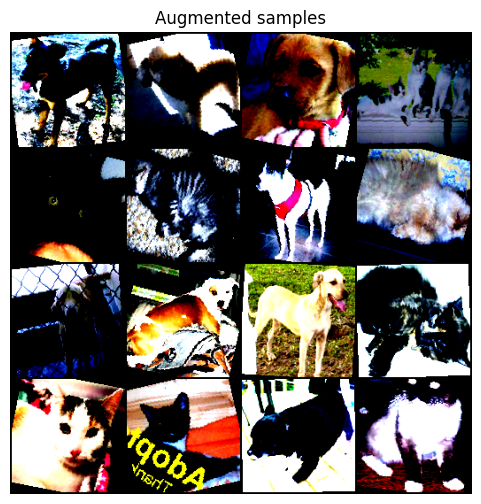

In [11]:
def show_batch(loader, title):
    images, labels = next(iter(loader))
    grid = make_grid(images[:16], nrow=4, normalize=True, value_range=(0, 1))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis("off")
    plt.show()


show_batch(train_loader, "Augmented samples")


In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class MediumCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout / 2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class ComplexCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout / 2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


def build_model(name, num_classes, dropout=0.5):
    name = name.lower()
    if name == "simple":
        return SimpleCNN(num_classes=num_classes)
    if name == "medium":
        return MediumCNN(num_classes=num_classes, dropout=dropout)
    if name == "complex":
        return ComplexCNN(num_classes=num_classes, dropout=dropout)
    raise ValueError(f"unknown model: {name}")


In [13]:
def benchmark_batch_sizes(batch_sizes=(32, 64, 128), num_batches=20):
    results = []
    for bs in batch_sizes:
        loader, _, _, _ = build_dataloaders(batch_size=bs, use_augment=True)
        model = SimpleCNN(num_classes=len(class_names)).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        model.train()

        losses = []
        start = time.time()
        for i, (x, y) in enumerate(loader):
            if i >= num_batches:
                break
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        duration = time.time() - start

        results.append({
            "batch_size": bs,
            "batches": len(losses),
            "avg_loss": float(np.mean(losses)) if losses else None,
            "loss_std": float(np.std(losses)) if losses else None,
            "sec_per_batch": duration / max(1, len(losses)),
        })

    for r in results:
        print(
            f"bs={r['batch_size']:<4} batches={r['batches']:<3} "
            f"avg_loss={r['avg_loss']:.4f} std={r['loss_std']:.4f} "
            f"sec/batch={r['sec_per_batch']:.4f}"
        )


benchmark_batch_sizes()


bs=32   batches=20  avg_loss=0.6959 std=0.0070 sec/batch=1.5250
bs=64   batches=20  avg_loss=0.6919 std=0.0073 sec/batch=0.3108
bs=128  batches=20  avg_loss=0.6936 std=0.0042 sec/batch=0.6251


In [ ]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def compute_confusion_matrix(preds, targets, num_classes):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    for t, p in zip(targets, preds):
        cm[t, p] += 1
    return cm


def precision_recall_from_cm(cm):
    tp = cm.diag().float()
    precision = tp / cm.sum(0).float().clamp_min(1)
    recall = tp / cm.sum(1).float().clamp_min(1)
    return precision.cpu().numpy(), recall.cpu().numpy()


def train_one_epoch(model, loader, optimizer, criterion, l1_lambda=0.0):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        # L1 正则通过把参数绝对值和加入损失实现。
        if l1_lambda > 0:
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        running_acc += accuracy_from_logits(logits, y) * batch_size
        total += batch_size

    return running_loss / total, running_acc / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        batch_size = x.size(0)
        running_loss += loss.item() * batch_size
        running_acc += accuracy_from_logits(logits, y) * batch_size
        total += batch_size

    return running_loss / total, running_acc / total


@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds = []
    targets = []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        preds.append(logits.argmax(dim=1).cpu())
        targets.append(y)
    return torch.cat(preds), torch.cat(targets)


def fit(model, train_loader, val_loader, optimizer, criterion, epochs, l1_lambda=0.0, patience=5, save_path=None):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }
    best_val = float("inf")
    best_state = None
    no_improve = 0

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    start = time.time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, l1_lambda)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # 仅在验证损失显著下降时刷新 best_state，避免抖动导致频繁覆盖。
        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        print(
            f"epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} "
            f"| val loss {val_loss:.4f} acc {val_acc:.4f}"
        )

        # patience=0 可视为关闭 early stopping。
        if patience and no_improve >= patience:
            print("early stopping triggered")
            break

    train_time = time.time() - start
    max_mem = None
    if torch.cuda.is_available():
        max_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)

    if save_path and best_state is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        torch.save(best_state, save_path)

    return history, best_state, train_time, max_mem


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="val")
    plt.title(f"{title} - loss")
    plt.xlabel("epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["val_acc"], label="val")
    plt.title(f"{title} - acc")
    plt.xlabel("epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_compare(histories, title):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    for label, hist in histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train", alpha=0.7)
        plt.plot(epochs, hist["val_loss"], label=f"{label} val", linestyle="--", alpha=0.7)
    plt.title(f"{title} - loss")
    plt.xlabel("epoch")
    plt.legend(fontsize=8)

    plt.subplot(1, 2, 2)
    for label, hist in histories.items():
        epochs = range(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train", alpha=0.7)
        plt.plot(epochs, hist["val_acc"], label=f"{label} val", linestyle="--", alpha=0.7)
    plt.title(f"{title} - acc")
    plt.xlabel("epoch")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
RUN_EXPERIMENTS = True


def make_optimizer(name, params, lr, weight_decay):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)


def run_experiment(cfg):
    train_loader, val_loader, test_loader, class_names = build_dataloaders(
        batch_size=cfg["batch_size"],
        use_augment=cfg["use_augment"],
        seed=cfg.get("seed", 42),
    )

    model = build_model(cfg["model"], num_classes=len(class_names), dropout=cfg.get("dropout", 0.0)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(cfg["optimizer"], model.parameters(), cfg["lr"], cfg["weight_decay"])

    save_path = f"checkpoints/{cfg['name']}.pt"
    history, best_state, train_time, max_mem = fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=cfg["epochs"],
        l1_lambda=cfg.get("l1_lambda", 0.0),
        patience=cfg.get("patience", PATIENCE),
        save_path=save_path,
    )

    # 统一用验证集最优参数做最终评估，避免用最后一个 epoch 的偶然状态。
    if best_state is not None:
        model.load_state_dict(best_state)

    val_loss, val_acc = evaluate(model, val_loader, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    preds, targets = predict_all(model, test_loader)
    cm = compute_confusion_matrix(preds, targets, num_classes=len(class_names))
    precision, recall = precision_recall_from_cm(cm)

    result = {
        "name": cfg["name"],
        "model": cfg["model"],
        "dropout": cfg.get("dropout", 0.0),
        "optimizer": cfg["optimizer"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "l1_lambda": cfg.get("l1_lambda", 0.0),
        "val_acc": val_acc,
        "test_acc": test_acc,
        "precision": precision,
        "recall": recall,
        "cm": cm,
        "history": history,
        "train_time_sec": train_time,
        "max_mem_mb": max_mem,
        "ckpt_path": save_path,
    }
    return result


experiment_results = []

if RUN_EXPERIMENTS:
    experiments = [
        {
            "name": "simple_l2",
            "model": "simple",
            "optimizer": "adam",
            "lr": LR,
            "weight_decay": 1e-4,
            "dropout": 0.0,
            "l1_lambda": 0.0,
            "use_augment": True,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "patience": PATIENCE,
        },
        {
            "name": "medium_dropout",
            "model": "medium",
            "optimizer": "adam",
            "lr": LR,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "l1_lambda": 0.0,
            "use_augment": True,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "patience": PATIENCE,
        },
        {
            "name": "complex_full",
            "model": "complex",
            "optimizer": "adamw",
            "lr": LR,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "l1_lambda": 1e-6,
            "use_augment": True,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "patience": PATIENCE,
        },
    ]

    for cfg in experiments:
        print("\n==>", cfg["name"])
        experiment_results.append(run_experiment(cfg))


==> simple_l2


epoch 01 | train loss 0.6864 acc 0.5445 | val loss 0.6642 acc 0.6000
epoch 02 | train loss 0.6672 acc 0.5923 | val loss 0.6713 acc 0.5790
epoch 03 | train loss 0.6577 acc 0.5965 | val loss 0.6478 acc 0.5920
epoch 04 | train loss 0.6462 acc 0.6075 | val loss 0.6335 acc 0.6280
epoch 05 | train loss 0.6339 acc 0.6410 | val loss 0.6367 acc 0.6350
epoch 06 | train loss 0.6339 acc 0.6428 | val loss 0.6316 acc 0.6230
epoch 07 | train loss 0.6424 acc 0.6178 | val loss 0.6326 acc 0.6350
epoch 08 | train loss 0.6266 acc 0.6490 | val loss 0.6175 acc 0.6590

==> medium_dropout
epoch 01 | train loss 0.6668 acc 0.5797 | val loss 0.6314 acc 0.6350
epoch 02 | train loss 0.6430 acc 0.6270 | val loss 0.6345 acc 0.6470
epoch 03 | train loss 0.6312 acc 0.6420 | val loss 0.6191 acc 0.6490
epoch 04 | train loss 0.6212 acc 0.6510 | val loss 0.5950 acc 0.6750
epoch 05 | train loss 0.6130 acc 0.6600 | val loss 0.5974 acc 0.6660
epoch 06 | train loss 0.5989 acc 0.6765 | val loss 0.6279 acc 0.6320
epoch 07 | tra

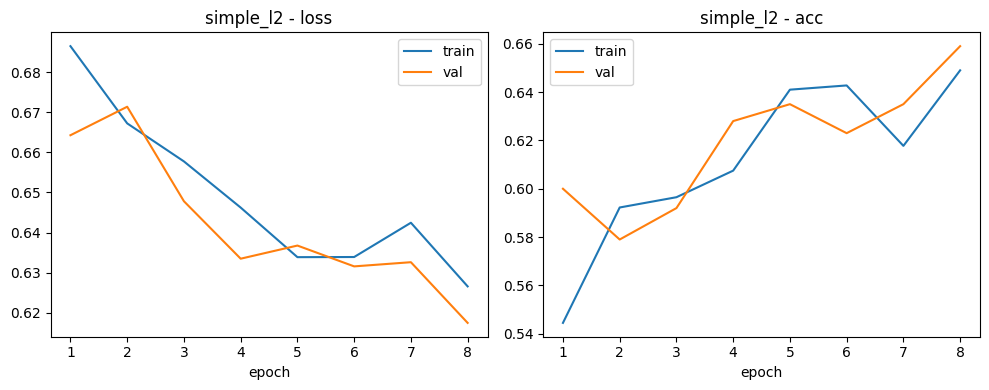

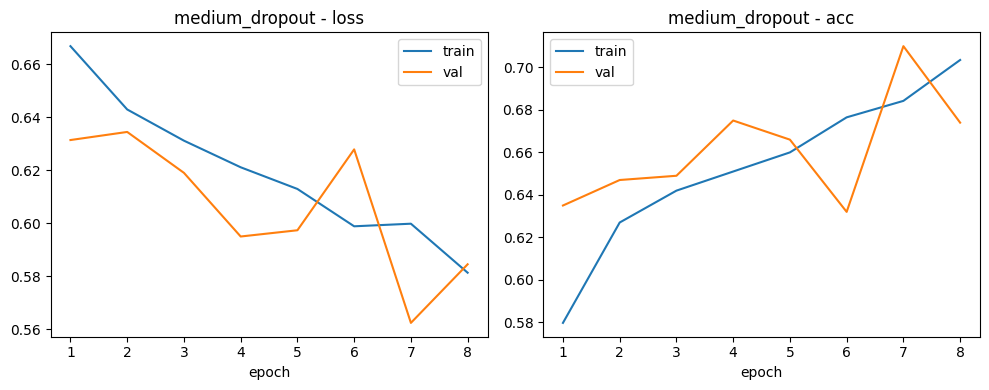

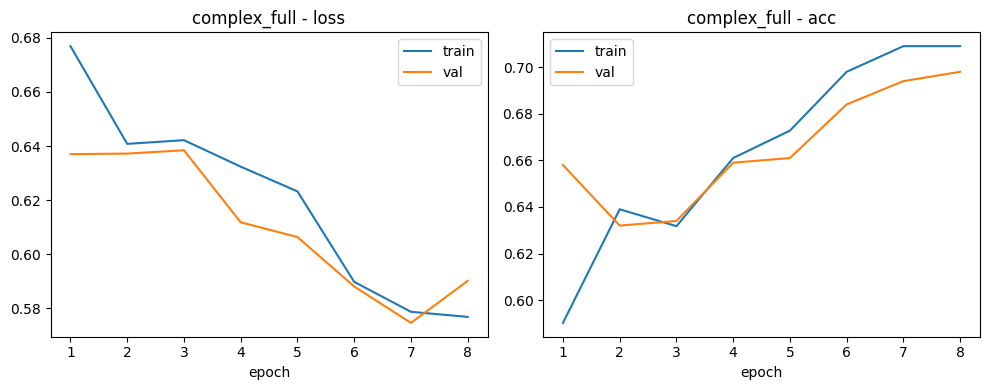

In [16]:
for r in experiment_results:
    plot_history(r["history"], r["name"])



==> dropout medium p=0.2
epoch 01 | train loss 0.6667 acc 0.5883 | val loss 0.6715 acc 0.5580
epoch 02 | train loss 0.6332 acc 0.6305 | val loss 0.7186 acc 0.5740
epoch 03 | train loss 0.6183 acc 0.6627 | val loss 0.6040 acc 0.6700
epoch 04 | train loss 0.6014 acc 0.6773 | val loss 0.6404 acc 0.6580
epoch 05 | train loss 0.6015 acc 0.6800 | val loss 0.5686 acc 0.7160
epoch 06 | train loss 0.5748 acc 0.6993 | val loss 0.5668 acc 0.6990
epoch 07 | train loss 0.5684 acc 0.7070 | val loss 0.5733 acc 0.7070
epoch 08 | train loss 0.5609 acc 0.7130 | val loss 0.5664 acc 0.7060

==> dropout medium p=0.5
epoch 01 | train loss 0.6728 acc 0.5823 | val loss 0.6453 acc 0.6180
epoch 02 | train loss 0.6453 acc 0.6218 | val loss 0.6301 acc 0.6320
epoch 03 | train loss 0.6435 acc 0.6285 | val loss 0.6222 acc 0.6390
epoch 04 | train loss 0.6239 acc 0.6510 | val loss 0.6982 acc 0.5800
epoch 05 | train loss 0.6043 acc 0.6760 | val loss 0.6927 acc 0.6180
epoch 06 | train loss 0.6062 acc 0.6705 | val loss 

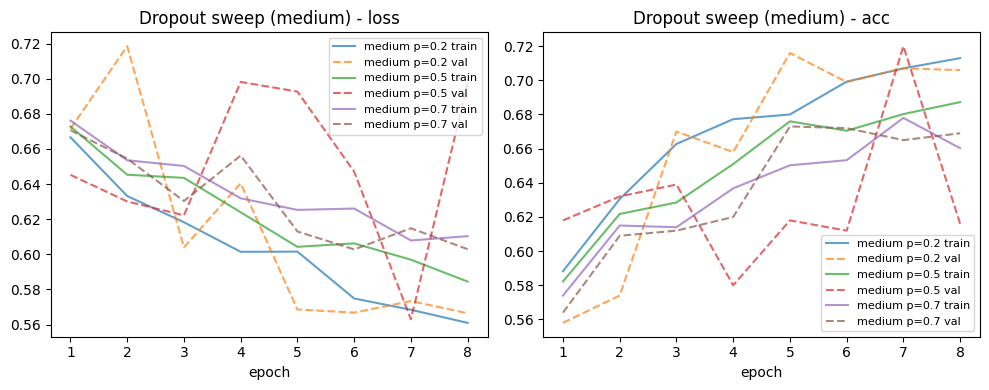


==> dropout complex p=0.2
epoch 01 | train loss 0.6749 acc 0.5757 | val loss 0.6630 acc 0.5710
epoch 02 | train loss 0.6500 acc 0.6068 | val loss 0.6825 acc 0.5300
epoch 03 | train loss 0.6547 acc 0.6092 | val loss 0.6447 acc 0.6310
epoch 04 | train loss 0.6433 acc 0.6165 | val loss 0.6376 acc 0.6270
epoch 05 | train loss 0.6306 acc 0.6405 | val loss 0.6485 acc 0.6340
epoch 06 | train loss 0.6247 acc 0.6488 | val loss 0.6636 acc 0.6020
epoch 07 | train loss 0.6053 acc 0.6715 | val loss 0.6934 acc 0.5820
epoch 08 | train loss 0.5977 acc 0.6787 | val loss 0.6098 acc 0.6790

==> dropout complex p=0.5
epoch 01 | train loss 0.6738 acc 0.5830 | val loss 0.6648 acc 0.5650
epoch 02 | train loss 0.6507 acc 0.6155 | val loss 0.6739 acc 0.5680
epoch 03 | train loss 0.6412 acc 0.6328 | val loss 0.6397 acc 0.6280
epoch 04 | train loss 0.6251 acc 0.6532 | val loss 0.6097 acc 0.6620
epoch 05 | train loss 0.6153 acc 0.6667 | val loss 0.5845 acc 0.7010
epoch 06 | train loss 0.5937 acc 0.6853 | val los

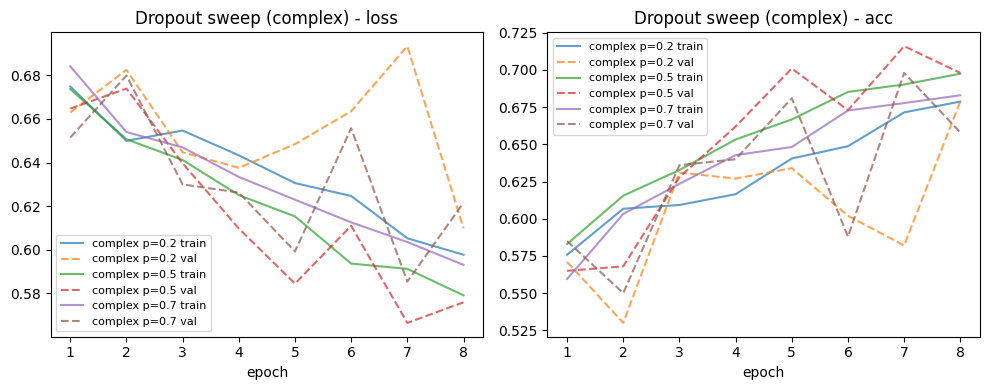


==> early stopping no_early_stop
epoch 01 | train loss 0.6702 acc 0.5935 | val loss 0.6445 acc 0.6170
epoch 02 | train loss 0.6555 acc 0.6060 | val loss 0.6367 acc 0.6390
epoch 03 | train loss 0.6425 acc 0.6395 | val loss 0.6148 acc 0.6720
epoch 04 | train loss 0.6291 acc 0.6442 | val loss 0.6076 acc 0.6710
epoch 05 | train loss 0.6243 acc 0.6515 | val loss 0.6119 acc 0.6680
epoch 06 | train loss 0.6004 acc 0.6800 | val loss 0.6268 acc 0.6510
epoch 07 | train loss 0.6047 acc 0.6830 | val loss 0.5828 acc 0.6790
epoch 08 | train loss 0.5937 acc 0.6905 | val loss 0.6250 acc 0.6500

==> early stopping patience=5
epoch 01 | train loss 0.6703 acc 0.5827 | val loss 0.6547 acc 0.6210
epoch 02 | train loss 0.6576 acc 0.6060 | val loss 0.6374 acc 0.6230
epoch 03 | train loss 0.6375 acc 0.6312 | val loss 0.6452 acc 0.6280
epoch 04 | train loss 0.6313 acc 0.6425 | val loss 0.6632 acc 0.5860
epoch 05 | train loss 0.6151 acc 0.6585 | val loss 0.5940 acc 0.6800
epoch 06 | train loss 0.5995 acc 0.676

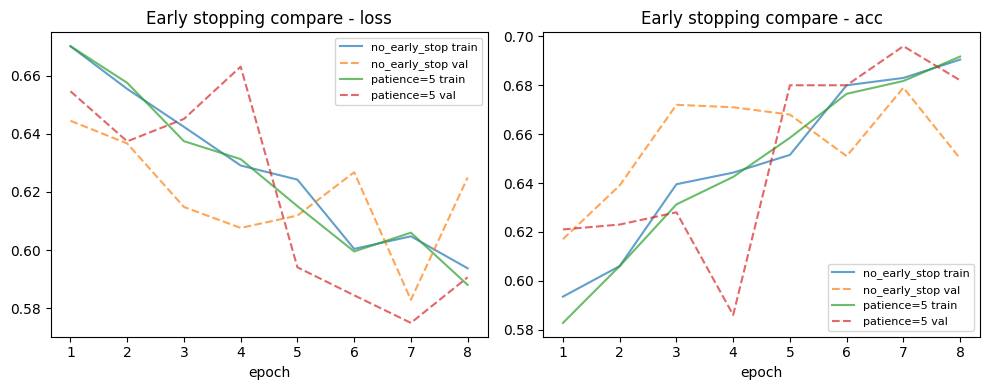


==> augmentation use_augment=False
epoch 01 | train loss 0.6604 acc 0.6078 | val loss 0.6769 acc 0.5720
epoch 02 | train loss 0.6128 acc 0.6613 | val loss 0.6364 acc 0.6450
epoch 03 | train loss 0.5738 acc 0.7005 | val loss 0.6768 acc 0.6240

==> augmentation use_augment=True
epoch 01 | train loss 0.6786 acc 0.5703 | val loss 0.6854 acc 0.5630
epoch 02 | train loss 0.6584 acc 0.5965 | val loss 0.6401 acc 0.6170
epoch 03 | train loss 0.6477 acc 0.6180 | val loss 0.6234 acc 0.6490


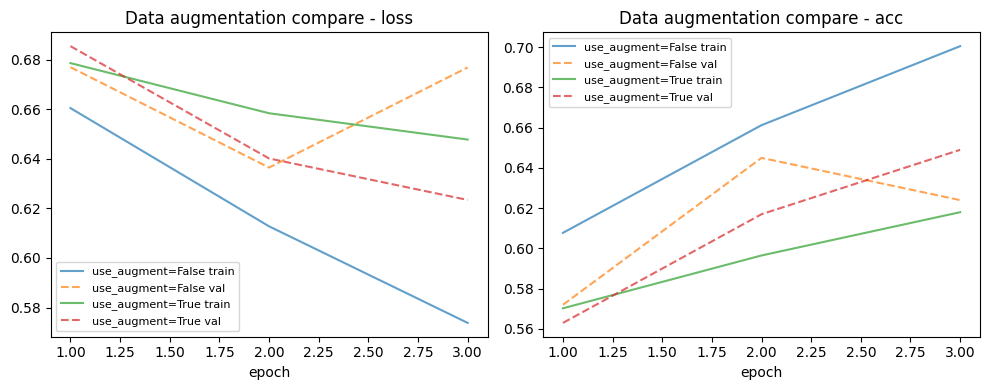

In [ ]:
RUN_TASKS = True

if RUN_TASKS:
    base_cfg = {
        "model": "medium",
        "optimizer": "adam",
        "lr": LR,
        "weight_decay": 1e-4,
        "dropout": 0.5,
        "l1_lambda": 0.0,
        "use_augment": True,
        "batch_size": BATCH_SIZE,
        "epochs": NUM_EPOCHS,
        "patience": PATIENCE,
    }

    def make_cfg(name, **overrides):
        cfg = dict(base_cfg)
        cfg.update({"name": name})
        cfg.update(overrides)
        return cfg

    task_results = {}

    dropout_values = [0.2, 0.5, 0.7]
    dropout_results = {}
    for model in ["medium", "complex"]:
        histories = {}
        for d in dropout_values:
            cfg = make_cfg(
                name=f"{model}_dropout_{d}",
                model=model,
                dropout=d,
            )
            print(f"\n==> dropout {model} p={d}")
            res = run_experiment(cfg)
            dropout_results[(model, d)] = res
            histories[f"{model} p={d}"] = res["history"]
        # 同一模型下只改变 dropout，观察欠拟合/过拟合变化。
        plot_compare(histories, f"Dropout sweep ({model})")
    task_results["dropout"] = dropout_results

    # Task 3: Early stopping compare.
    early_stop_results = {}
    histories = {}
    for patience in [0, PATIENCE]:
        label = "no_early_stop" if patience == 0 else f"patience={patience}"
        cfg = make_cfg(
            name=f"early_stop_{patience if patience else 'off'}",
            patience=patience,
        )
        print(f"\n==> early stopping {label}")
        res = run_experiment(cfg)
        early_stop_results[label] = res
        histories[label] = res["history"]
    plot_compare(histories, "Early stopping compare")
    task_results["early_stopping"] = early_stop_results

    # Task 4: Data augmentation compare.
    AUG_COMPARE_EPOCHS = min(NUM_EPOCHS, 3)
    aug_results = {}
    histories = {}
    for use_aug in [False, True]:
        label = f"use_augment={use_aug}"
        cfg = make_cfg(
            name=f"augment_{use_aug}",
            use_augment=use_aug,
            epochs=AUG_COMPARE_EPOCHS,
        )
        print(f"\n==> augmentation {label}")
        res = run_experiment(cfg)
        aug_results[use_aug] = res
        histories[label] = res["history"]
    # 为了公平比较增强策略，这里固定较短 epoch，减少训练时长差异影响。
    plot_compare(histories, "Data augmentation compare")
    task_results["augmentation"] = aug_results

In [18]:
RUN_L2_SWEEP = True

if RUN_L2_SWEEP:
    l2_results = []
    for wd in [1e-5, 1e-4, 1e-3]:
        cfg = {
            "name": f"l2_{wd}",
            "model": "medium",
            "optimizer": "adam",
            "lr": LR,
            "weight_decay": wd,
            "dropout": 0.5,
            "l1_lambda": 0.0,
            "use_augment": True,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "patience": PATIENCE,
        }
        res = run_experiment(cfg)
        l2_results.append((wd, res["val_acc"], res["test_acc"]))

    for wd, v, t in l2_results:
        print(f"weight_decay={wd:.0e} val_acc={v:.4f} test_acc={t:.4f}")


epoch 01 | train loss 0.6746 acc 0.5845 | val loss 0.6752 acc 0.5630
epoch 02 | train loss 0.6460 acc 0.6148 | val loss 0.8482 acc 0.5180
epoch 03 | train loss 0.6433 acc 0.6250 | val loss 0.6626 acc 0.5900
epoch 04 | train loss 0.6339 acc 0.6315 | val loss 0.7396 acc 0.5570
epoch 05 | train loss 0.6215 acc 0.6550 | val loss 1.1246 acc 0.5150
epoch 06 | train loss 0.6081 acc 0.6670 | val loss 0.5830 acc 0.6930
epoch 07 | train loss 0.5953 acc 0.6810 | val loss 0.5782 acc 0.6840
epoch 08 | train loss 0.5893 acc 0.6915 | val loss 0.5733 acc 0.6740
epoch 01 | train loss 0.6793 acc 0.5657 | val loss 0.6483 acc 0.6150
epoch 02 | train loss 0.6556 acc 0.6075 | val loss 0.6860 acc 0.5530
epoch 03 | train loss 0.6421 acc 0.6328 | val loss 0.6982 acc 0.5800
epoch 04 | train loss 0.6362 acc 0.6458 | val loss 0.7410 acc 0.5740
epoch 05 | train loss 0.6132 acc 0.6570 | val loss 0.5896 acc 0.6930
epoch 06 | train loss 0.6064 acc 0.6715 | val loss 0.6412 acc 0.6340
epoch 07 | train loss 0.5865 acc 0

In [ ]:
RUN_L1_COMPARE = True

if RUN_L1_COMPARE:
    l1_results = []
    for l1_lambda in [0.0, 1e-7, 1e-6, 1e-5]:
        cfg = {
            "name": f"l1_{l1_lambda}",
            "model": "medium",
            "optimizer": "adam",
            "lr": LR,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "l1_lambda": l1_lambda,
            "use_augment": True,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "patience": PATIENCE,
        }
        res = run_experiment(cfg)
        l1_results.append((l1_lambda, res["val_acc"], res["test_acc"]))

    for l1_lambda, v, t in l1_results:
        print(f"l1_lambda={l1_lambda:.0e} val_acc={v:.4f} test_acc={t:.4f}")


epoch 01 | train loss 0.6712 acc 0.5905 | val loss 0.7167 acc 0.5530
epoch 02 | train loss 0.6510 acc 0.6160 | val loss 0.6626 acc 0.5920
epoch 03 | train loss 0.6385 acc 0.6258 | val loss 0.7145 acc 0.5480
epoch 04 | train loss 0.6378 acc 0.6338 | val loss 0.7185 acc 0.5610
epoch 05 | train loss 0.6176 acc 0.6625 | val loss 0.6024 acc 0.6730
epoch 06 | train loss 0.6069 acc 0.6703 | val loss 0.5867 acc 0.6950
epoch 07 | train loss 0.6100 acc 0.6783 | val loss 0.6392 acc 0.6560
epoch 08 | train loss 0.5968 acc 0.6820 | val loss 0.6908 acc 0.6110
epoch 01 | train loss 0.6664 acc 0.5817 | val loss 0.6527 acc 0.6100
epoch 02 | train loss 0.6449 acc 0.6252 | val loss 0.6827 acc 0.5820
epoch 03 | train loss 0.6411 acc 0.6252 | val loss 0.6244 acc 0.6480
epoch 04 | train loss 0.6239 acc 0.6460 | val loss 0.6664 acc 0.6220
epoch 05 | train loss 0.6104 acc 0.6657 | val loss 0.6244 acc 0.6610
epoch 06 | train loss 0.6041 acc 0.6713 | val loss 0.7230 acc 0.5510
epoch 07 | train loss 0.5969 acc 0

In [ ]:
RUN_AUG_COMPARE = False
AUG_COMPARE_EPOCHS = min(NUM_EPOCHS, 3)

if RUN_AUG_COMPARE:
    aug_results = []
    for use_aug in [False, True]:
        cfg = {
            "name": f"augment_{use_aug}",
            "model": "medium",
            "optimizer": "adam",
            "lr": LR,
            "weight_decay": 1e-4,
            "dropout": 0.5,
            "l1_lambda": 0.0,
            "use_augment": use_aug,
            "batch_size": BATCH_SIZE,
            "epochs": AUG_COMPARE_EPOCHS,
            "patience": PATIENCE,
        }
        res = run_experiment(cfg)
        aug_results.append((use_aug, res["val_acc"], res["test_acc"]))

    for use_aug, v, t in aug_results:
        print(f"use_augment={use_aug} val_acc={v:.4f} test_acc={t:.4f}")

epoch 01 | train loss 0.6720 acc 0.5887 | val loss 0.6326 acc 0.6320
epoch 02 | train loss 0.6235 acc 0.6615 | val loss 0.6202 acc 0.6440
epoch 03 | train loss 0.5910 acc 0.6925 | val loss 0.5779 acc 0.7040
epoch 01 | train loss 0.6706 acc 0.5857 | val loss 0.6398 acc 0.6350
epoch 02 | train loss 0.6457 acc 0.6152 | val loss 0.7584 acc 0.5610
epoch 03 | train loss 0.6355 acc 0.6310 | val loss 0.6280 acc 0.6380
use_augment=False val_acc=0.7040 test_acc=0.7175
use_augment=True val_acc=0.6380 test_acc=0.6725


In [ ]:
RUN_TUNING = True

if RUN_TUNING:
    tuning_results = []
    for lr in [1e-2, 1e-3, 1e-4]:
        for opt in ["sgd", "adam", "adamw"]:
            cfg = {
                "name": f"tune_{opt}_{lr}",
                "model": "medium",
                "optimizer": opt,
                "lr": lr,
                "weight_decay": 1e-4,
                "dropout": 0.5,
                "l1_lambda": 0.0,
                "use_augment": True,
                "batch_size": BATCH_SIZE,
                "epochs": NUM_EPOCHS,
                "patience": PATIENCE,
            }
            res = run_experiment(cfg)
            tuning_results.append((opt, lr, res["val_acc"], res["test_acc"]))

    for opt, lr, v, t in tuning_results:
        print(f"opt={opt:<5} lr={lr:.0e} val_acc={v:.4f} test_acc={t:.4f}")

    opts = sorted({opt for opt, _, _, _ in tuning_results})
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    for opt in opts:
        lrs = np.array([lr for o, lr, _, _ in tuning_results if o == opt])
        vals = np.array([v for o, _, v, _ in tuning_results if o == opt])
        order = np.argsort(lrs)
        # 用对数横轴展示学习率，便于比较不同数量级上的最优点。
        plt.semilogx(lrs[order], vals[order], marker="o", label=opt)
    plt.title("Tuning - val acc")
    plt.xlabel("lr")
    plt.ylabel("val acc")
    plt.legend()

    plt.subplot(1, 2, 2)
    for opt in opts:
        lrs = np.array([lr for o, lr, _, _ in tuning_results if o == opt])
        tests = np.array([t for o, _, _, t in tuning_results if o == opt])
        order = np.argsort(lrs)
        plt.semilogx(lrs[order], tests[order], marker="o", label=opt)
    plt.title("Tuning - test acc")
    plt.xlabel("lr")
    plt.ylabel("test acc")
    plt.legend()

    plt.tight_layout()
    plt.show()

epoch 01 | train loss 0.6834 acc 0.5640 | val loss 0.6630 acc 0.5890
epoch 02 | train loss 0.6622 acc 0.5913 | val loss 0.6382 acc 0.6260
epoch 03 | train loss 0.6492 acc 0.6168 | val loss 0.6414 acc 0.6100
epoch 04 | train loss 0.6392 acc 0.6310 | val loss 0.6814 acc 0.6030


epoch 05 | train loss 0.6346 acc 0.6322 | val loss 0.6289 acc 0.6180
epoch 06 | train loss 0.6263 acc 0.6420 | val loss 0.6189 acc 0.6310
epoch 07 | train loss 0.6305 acc 0.6400 | val loss 0.6024 acc 0.6710
epoch 08 | train loss 0.6105 acc 0.6657 | val loss 0.6198 acc 0.6640
epoch 01 | train loss 0.7136 acc 0.4993 | val loss 0.6917 acc 0.5190
epoch 02 | train loss 0.6941 acc 0.5080 | val loss 0.6896 acc 0.5150
epoch 03 | train loss 0.6930 acc 0.5105 | val loss 0.6938 acc 0.4910
epoch 04 | train loss 0.6934 acc 0.4935 | val loss 0.6931 acc 0.5100
epoch 05 | train loss 0.6932 acc 0.5208 | val loss 0.6932 acc 0.5090
epoch 06 | train loss 0.6935 acc 0.4853 | val loss 0.6934 acc 0.4910
epoch 07 | train loss 0.6929 acc 0.5098 | val loss 0.6954 acc 0.4910
early stopping triggered
epoch 01 | train loss 0.7074 acc 0.5315 | val loss 0.6827 acc 0.5670
epoch 02 | train loss 0.6827 acc 0.5570 | val loss 0.6670 acc 0.5440
epoch 03 | train loss 0.6801 acc 0.5675 | val loss 0.6717 acc 0.5500
epoch 04 

best: complex_full val_acc= 0.714 test_acc= 0.7425
precision: [0.7214612 0.7679558] recall: [0.79  0.695]


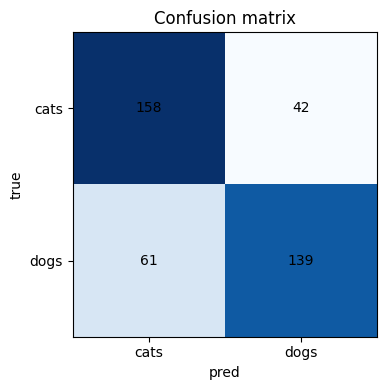

loaded model test acc: 0.7425


In [ ]:
if experiment_results:
    best = max(experiment_results, key=lambda r: r["val_acc"])
    print("best:", best["name"], "val_acc=", best["val_acc"], "test_acc=", best["test_acc"])
    print("precision:", best["precision"], "recall:", best["recall"])

    cm = best["cm"].cpu().numpy()
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion matrix")
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1], class_names)
    plt.yticks([0, 1], class_names)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()

    _, _, test_loader_default, _ = build_dataloaders()
    model = build_model(best["model"], num_classes=len(class_names), dropout=best.get("dropout", 0.5))
    model.load_state_dict(torch.load(best["ckpt_path"], map_location=device))
    model.to(device)
    test_loss, test_acc = evaluate(model, test_loader_default, nn.CrossEntropyLoss())
    print("loaded model test acc:", test_acc)
